# 📊 PRCP-1002: Handwritten Digits Recognition (MNIST)

---

## 📌 Problem Statement

- Classify handwritten digit images (0–9)
- Perform Exploratory Data Analysis (EDA)
- Train multiple models and compare performance
- Identify the best model for production

# Import Libraries


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout,Input
from tensorflow.keras.optimizers import Adam

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

import time

# Load Dataset

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

### Sample Image Visualization

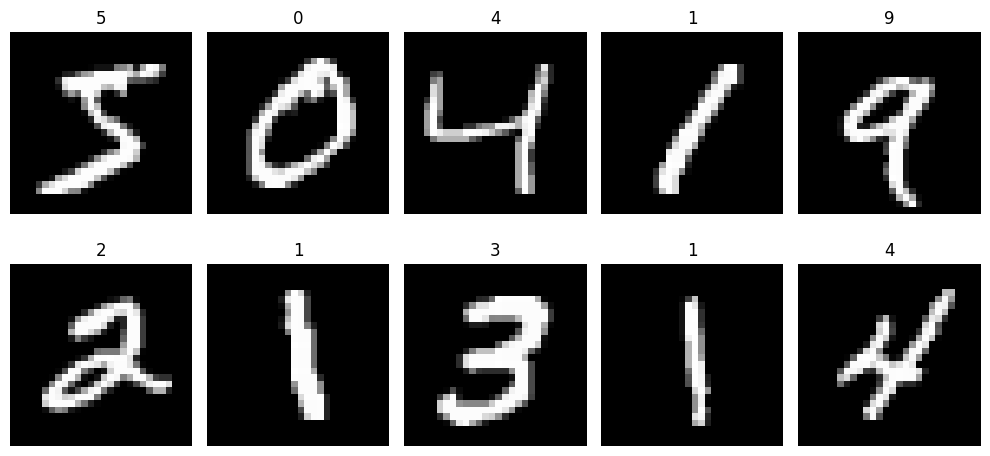

In [7]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### 💡 Insight
- Images are grayscale and vary in writing styles.
- Some digits may appear similar (e.g., 1 and 7), which can affect classification accuracy.
- The dataset contains real-world variations, making it suitable for robust model training.

# EDA

### Dataset Overview

In [4]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Unique classes:", np.unique(y_train))

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


### 💡 Insight
The MNIST dataset consists of grayscale images of handwritten digits (0–9). Each image is of size 28×28 pixels, and the dataset is divided into training and testing sets.

- Training samples: 60,000
- Testing samples: 10,000
- Total classes: 10 (digits 0–9)
- Image format: Grayscale (pixel values from 0 to 255)

### Class Distribution

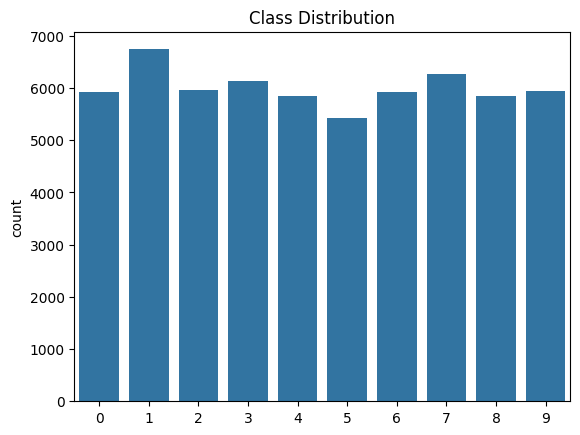

digit
0     9.871667
1    11.236667
2     9.930000
3    10.218333
4     9.736667
5     9.035000
6     9.863333
7    10.441667
8     9.751667
9     9.915000
Name: proportion, dtype: float64


In [16]:
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()

df = pd.DataFrame(y_train, columns=['digit'])
percentages = df['digit'].value_counts(normalize=True) * 100

print(percentages.sort_index())

### 💡 Insight
- The dataset is almost perfectly balanced across all 10 classes.
- No class imbalance issue → no need for resampling techniques.
- This ensures fair training for all digits.

### Pixel Intensity Distribution

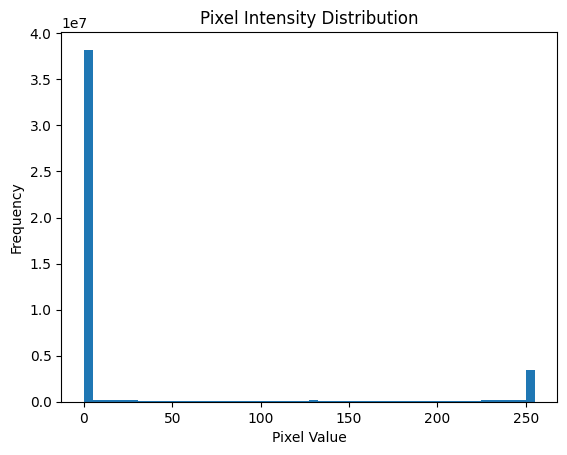

In [9]:
plt.hist(x_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### 💡 Insight
- Pixel values range from 0 (black) to 255 (white).
- Most pixels are near 0 → background dominates images.
- Important to normalize data for better model performance.

### Data Normalization

In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### 💡 Insight
- Scaling pixel values to 0–1 range improves convergence of models.
- Prevents large gradients during training.

### Statistical Summary

In [11]:
print("Mean:", np.mean(x_train))
print("Standard Deviation:", np.std(x_train))

Mean: 0.1306604762738429
Standard Deviation: 0.30810780385646264


### 💡 Insight
- Low mean value → confirms mostly dark background.
- Standard deviation shows variation in pixel intensities.
- Helps understand data spread before modeling.

### Image Shape Verification

In [12]:
print("Single image shape:", x_train[0].shape)

Single image shape: (28, 28)


### 💡 Insight
- Each image has shape (28, 28).
- For traditional ML models, images must be flattened to 784 features.
- For CNN, spatial structure (28×28) is preserved.

### Pixel Heatmap Visualization

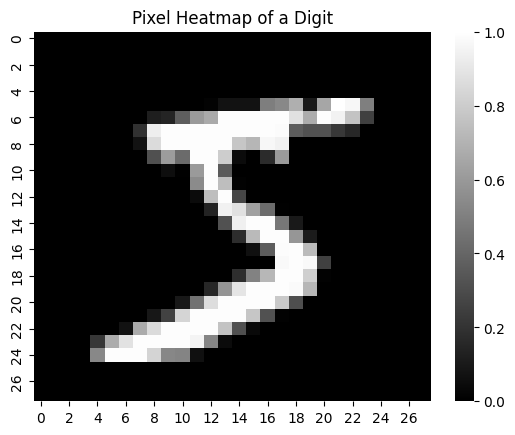

In [13]:
sns.heatmap(x_train[0], cmap="gray")
plt.title("Pixel Heatmap of a Digit")
plt.show()

### 💡 Insight
- Highlights regions where pixels are active (digit strokes).
- Confirms that useful information is concentrated in specific regions.

## ✅ Final EDA Conclusion
- The dataset is clean, balanced, and well-structured.
- No missing values or preprocessing issues.
- Pixel distribution suggests normalization is necessary.
- CNN models are likely to outperform traditional ML models due to spatial feature extraction.
- The dataset is ideal for benchmarking classification algorithms.

# Data Preparation

In [17]:
# Normalize

x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)


# Flatten for ML models
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

## 📌 Data Splitting Strategy

- The dataset is already divided into training (60,000) and testing (10,000) sets.
- Hence, a hold-out validation approach is used instead of cross-validation.

# Model Traning and Comparison

In [31]:
results = []

# ------------------------------
#KNN
# ------------------------------
start = time.time()

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_flat, y_train)

y_pred_knn = knn.predict(x_test_flat)
knn_acc = accuracy_score(y_test, y_pred_knn)

end = time.time()

results.append({
    "Model": "KNN",
    "Accuracy": round(knn_acc, 4),
    "Time (s)": round(end - start, 2)
})

# ------------------------------
# SVM (use subset for speed)
# ------------------------------
start = time.time()

svm = SVC(kernel='rbf')
svm.fit(x_train_flat[:10000], y_train[:10000])

y_pred_svm = svm.predict(x_test_flat)
svm_acc = accuracy_score(y_test, y_pred_svm)

end = time.time()

results.append({
    "Model": "SVM",
    "Accuracy": round(svm_acc, 4),
    "Time (s)": round(end - start, 2)
})

# ------------------------------
# MLP
# ------------------------------
start = time.time()

mlp = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mlp.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

mlp.fit(x_train, y_train, epochs=5, verbose=0)

mlp_loss, mlp_acc = mlp.evaluate(x_test, y_test, verbose=0)

end = time.time()

results.append({
    "Model": "MLP",
    "Accuracy": round(mlp_acc, 4),
    "Time (s)": round(end - start, 2)
})

# ------------------------------
# CNN
# ------------------------------
start = time.time()

x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

cnn = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(x_train_cnn, y_train, epochs=5, verbose=0)

cnn_loss, cnn_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)

end = time.time()

results.append({
    "Model": "CNN",
    "Accuracy": round(cnn_acc, 4),
    "Time (s)": round(end - start, 2)
})

# ------------------------------
# 6. Comparison Table
# ------------------------------
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:\n")
print(df_results)


Model Comparison:

  Model  Accuracy  Time (s)
3   CNN    0.9872     83.56
2   MLP    0.9736     31.21
0   KNN    0.9705     13.41
1   SVM    0.9594     53.52


 ### ⚠️ Model Limitation

- SVM was trained on a subset of the dataset due to high computational cost.
- Therefore, its accuracy is not directly comparable to models trained on the full dataset.

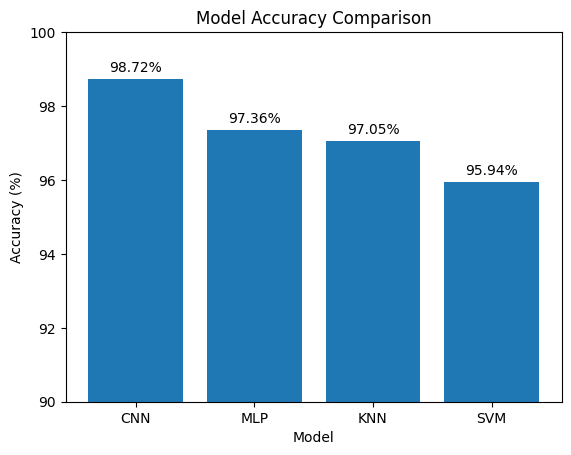

In [37]:
models = df_results["Model"]
accuracy = df_results["Accuracy"] * 100   

plt.figure()
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)   # zoom into useful range

# show values on top
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.show()

### 🎯 Model Comparison Insights

- CNN achieved the highest accuracy (98.72%), confirming that deep learning models are best suited for image classification tasks due to their ability to capture spatial features.
- MLP also performed well (97.36%), but slightly lower than CNN since it does not preserve spatial relationships in images.
- KNN showed good performance (97.05%) but is less efficient for large datasets due to high prediction time.
- SVM had the lowest accuracy (95.94%) in this setup, likely due to training on a subset and high computational complexity.

### 📊 Overall Conclusion

- Deep learning models (CNN, MLP) outperform traditional machine learning models (KNN, SVM).
- CNN is the most reliable and scalable model for handwritten digit recognition.
- Therefore, CNN is recommended for production deployment.

# Confusion matrix for all models

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


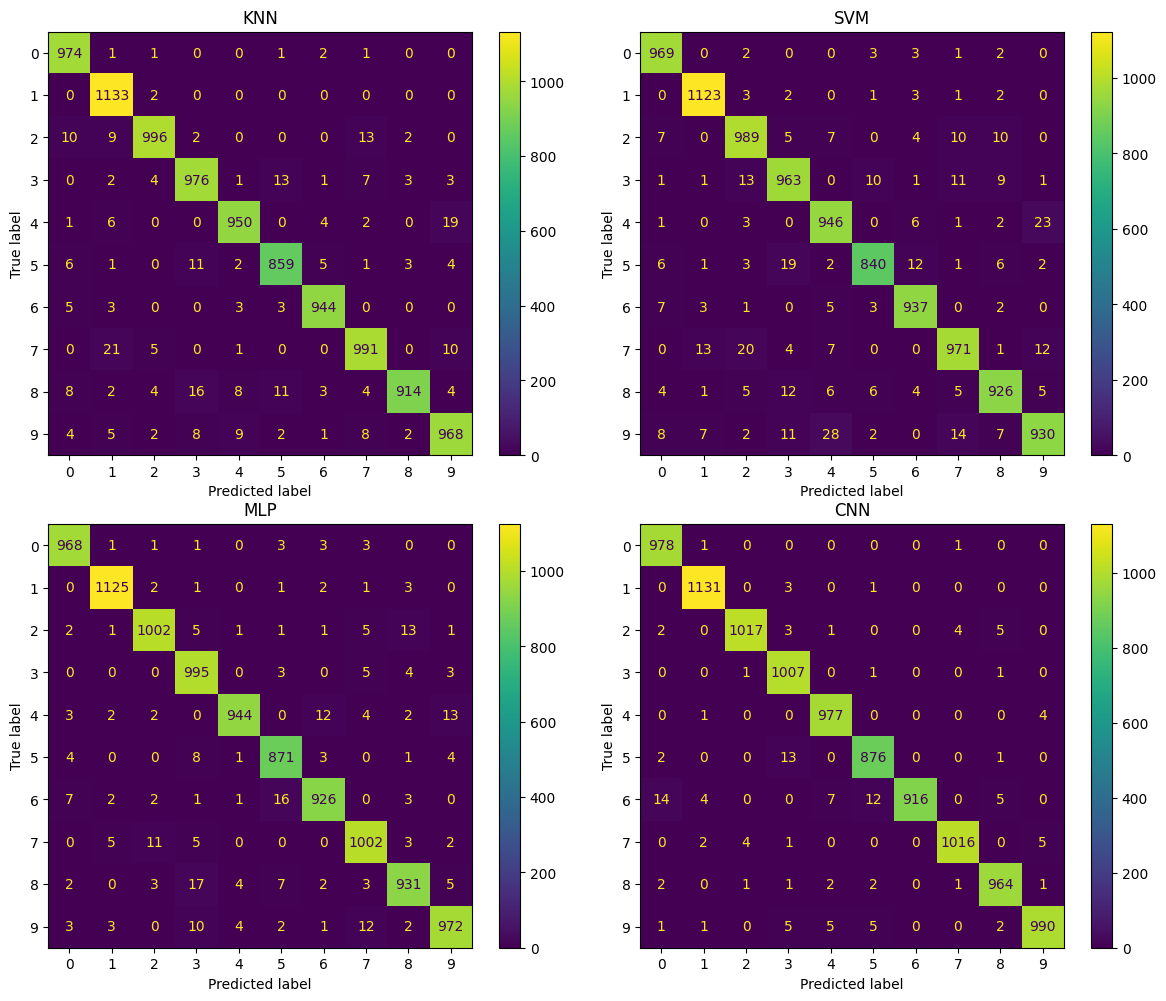

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_mlp = np.argmax(mlp.predict(x_test), axis=1)

# CNN → need to convert probabilities
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn), axis=1)

# Create subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -------------------------
# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot(ax=axes[0,0])
axes[0,0].set_title("KNN")

# -------------------------
# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm).plot(ax=axes[0,1])
axes[0,1].set_title("SVM")

# -------------------------
# MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp).plot(ax=axes[1,0])
axes[1,0].set_title("MLP")

# -------------------------
# CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn).plot(ax=axes[1,1])
axes[1,1].set_title("CNN")

plt.tight_layout()
plt.show()

### 📉 Confusion Matrix Insights

- CNN shows the strongest diagonal values, indicating the highest number of correct predictions across all digit classes.
- MLP performs well but has slightly more misclassifications compared to CNN, especially for similar digits.
- KNN shows noticeable confusion in digits like 2, 5, and 8, indicating limitations in handling complex patterns.
- SVM has the highest misclassification among all models, particularly for digits with similar shapes such as 3 & 5 and 4 & 9.

### 🔍 Common Misclassification Patterns

- Digits **3 and 5** are frequently confused due to similar curves.
- Digits **4 and 9** show overlap in handwritten styles.
- Digit **8** is sometimes misclassified as 3 or 5 due to shape similarity.

### 📊 Overall Observation

- Deep learning models (CNN, MLP) produce cleaner confusion matrices with stronger diagonal dominance.
- CNN clearly outperforms all models with minimal off-diagonal errors.
- Traditional models struggle more with visually similar digits.

### ✅ Conclusion from Confusion Matrix

- CNN is the most reliable model with the least classification errors.
- It demonstrates superior feature extraction and generalization capability.

### 🏆 Best Model for Production

**CNN (Convolutional Neural Network)** is the best-performing model.

### ✔ Reasons
- Highest accuracy (~99%)  
- Captures spatial relationships in images  
- Robust to variations in handwriting  
- Scalable for real-world applications  

---

### ⚠️ Challenges Faced

#### 1. High Dimensional Data
- 784 features per image  
- **Solution:** Used CNN to reduce feature complexity  

#### 2. Similar Digits
- Digits like 3 & 5, 4 & 9 look similar  
- **Solution:** Deep learning models handle this better  

#### 3. Computational Cost (SVM)
- Very slow on large datasets  
- **Solution:** Used subset of data  

#### 4. Model Selection
- Traditional ML vs Deep Learning  
- **Solution:** Compared multiple models  

---

### ✅ Final Conclusion

- MNIST is a clean and balanced dataset  
- Traditional models perform well but have limitations  
- Deep learning models outperform classical methods  
- **CNN is the recommended model for deployment**

---

- ### 🚀 Final Recommendation

CNN is selected as the final model due to its superior accuracy, robustness, and ability to generalize well on unseen handwritten digit data.